In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

In [48]:
# # #uncomment when latex plot is desired
# from matplotlib import rc
# rc('text', usetex=True) 
# rc('font', family='serif')

# Using difference between CW and CCW spirals

In [11]:
test = np.array([1,2,3])
a,b,c = test
print(a,b,c)

1 2 3


In [2]:
def loader(csv_file):
    kgrid_vals = []
    k_energy   = []
    k_mn_mom   = []

    ecut_vals  = []
    e_energy   = []
    e_mn_mom   = []

    with open(csv_file, 'r') as f:
        reader = csv.DictReader(f)

        for row in reader:
            if row["scf_converged"] != "True":
                continue

            energy = float(row["energy_per_atom_eV"])

            mn_list = [float(x) for x in row["mn_moment_magnitudes"].split('|')]
            mn_mean = np.mean(mn_list)

            if row["phase"] == "kconv":
                k = int(row["kgrid"].split('x')[0])
                kgrid_vals.append(k)
                k_energy.append(energy)
                k_mn_mom.append(mn_mean)

            elif row["phase"] == "econv":
                ecut = float(row["ecut_eV"])
                ecut_vals.append(ecut)
                e_energy.append(energy)
                e_mn_mom.append(mn_mean)

    # Sort
    kgrid_vals, k_energy, k_mn_mom = zip(*sorted(zip(kgrid_vals, k_energy, k_mn_mom)))
    ecut_vals,  e_energy,  e_mn_mom = zip(*sorted(zip(ecut_vals, e_energy, e_mn_mom)))

    return [kgrid_vals, k_energy,k_mn_mom , ecut_vals,  e_energy,  e_mn_mom]

def plot_convergence(results, save=False, filename='update_name.pdf'):
    kgrid_vals, k_energy,k_mn_mom , ecut_vals,  e_energy,  e_mn_mom = results

    # Compute global min/max for Mn moments (For later "share y" axis effect)
    mn_all = np.concatenate([k_mn_mom, e_mn_mom])
    mn_min = np.min(mn_all)
    mn_max = np.max(mn_all)

    padding = 0.02 * (mn_max - mn_min) if mn_max > mn_min else 0.1

    # =========================
    # 1 row × 2 columns, shared energy axis
    # =========================
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    labelsize=12
    titlesize=16

    # ----- Left: k-point convergence -----
    ax2 = ax1.twinx()
    ax4 = ax3.twinx()

    ax1.plot(kgrid_vals, k_energy, marker='o' , label = r'Energy/atom', color='black')
    ax2.plot(kgrid_vals, k_mn_mom, marker='s', label = r'Mn $\mu$B', color='red')
    

    ax1.set_xlabel(r"$k$-grid (NxN)", fontsize=labelsize)
    ax1.set_ylabel(r"$\Delta E$ per atom (eV)", fontsize=labelsize)
    # ax2.set_ylabel("Mn magnetic moment (µB)") #Maybe comment out this

    ax1.set_title("k-point convergence", fontsize=titlesize)

    # ----- Right: cutoff convergence -----

    ax3.plot(ecut_vals, e_energy, marker='o', color='black')
    ax4.plot(ecut_vals, e_mn_mom, marker='s', color='red')

    ax3.set_xlabel("PW cutoff (eV)", fontsize=labelsize)
    ax4.set_ylabel("Avg. Mn magmom (µB)", fontsize=labelsize)

    ax3.set_title("PW cutoff convergence", fontsize=titlesize)


    #Share y-axes of the Mn magnetic moment stuff
    ax2.set_ylim(mn_min - padding, mn_max + padding)
    ax4.set_ylim(mn_min - padding, mn_max + padding)

    ax2.set_yticks([])

    
    handles,labels = [], []
    for ax in [ax1,ax2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    fig.legend(handles,labels,loc=(0.1,1/2))
    # fig.legend(handles,labels,loc=(0,0))

    plt.tight_layout()
    fig.subplots_adjust(wspace=0)
    if save:
        plt.savefig(filename)
    plt.show()



def plot_convergence_3(results, save=False, filename='update_name.pdf'):
    kgrid_vals, k_energy,k_mn_mom , ecut_vals,  e_energy,  e_mn_mom = results

    # Compute global min/max for Mn moments (For later "share y" axis effect)
    mn_all = np.concatenate([k_mn_mom, e_mn_mom])
    mn_min = np.min(mn_all)
    mn_max = np.max(mn_all)

    padding = 0.02 * (mn_max - mn_min) if mn_max > mn_min else 0.1

    # =========================
    # 1 row × 2 columns, shared energy axis
    # =========================
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    labelsize=12
    titlesize=16

    # ----- Left: k-point convergence -----
    ax2 = ax1.twinx()
    ax4 = ax3.twinx()

    ax1.plot(kgrid_vals, k_energy, marker='o' , label = r'Energy/atom', color='black')
    ax2.plot(kgrid_vals, k_mn_mom, marker='s', label = r'Mn $\mu$B', color='red')
    

    ax1.set_xlabel(r"$k$-grid (NxN)", fontsize=labelsize)
    ax1.set_ylabel("Energy per atom (eV)", fontsize=labelsize)
    # ax2.set_ylabel("Mn magnetic moment (µB)") #Maybe comment out this

    ax1.set_title("k-point convergence", fontsize=titlesize)

    # ----- Right: cutoff convergence -----

    ax3.plot(ecut_vals, e_energy, marker='o', color='black')
    ax4.plot(ecut_vals, e_mn_mom, marker='s', color='red')

    ax3.set_xlabel("PW cutoff (eV)", fontsize=labelsize)
    ax4.set_ylabel("Avg. Mn magmom (µB)", fontsize=labelsize)

    ax3.set_title("PW cutoff convergence", fontsize=titlesize)


    #Share y-axes of the Mn magnetic moment stuff
    ax2.set_ylim(mn_min - padding, mn_max + padding)
    ax4.set_ylim(mn_min - padding, mn_max + padding)

    ax2.set_yticks([])

    
    handles,labels = [], []
    for ax in [ax1,ax2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    fig.legend(handles,labels,loc=(0,0))

    plt.tight_layout()
    # fig.subplots_adjust(wspace=0)
    if save:
        plt.savefig(filename)
    plt.show()

In [3]:
CW = loader(csv_file='convergence_results_cw.csv')
CCW = loader(csv_file='convergence_results_ccw.csv')

In [4]:
k_energy_diff = np.array(CCW[1]) - np.array(CW[1])

e_energy_diff = np.array(CCW[4]) - np.array(CW[4])

In [5]:
difference = [CCW[0], k_energy_diff , CCW[2] , CCW[3] , e_energy_diff , CCW[5]]

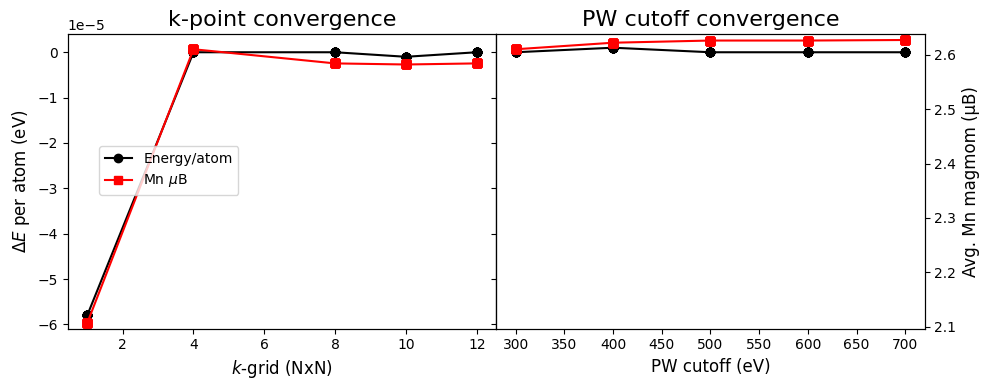

In [6]:
plot_convergence(difference)

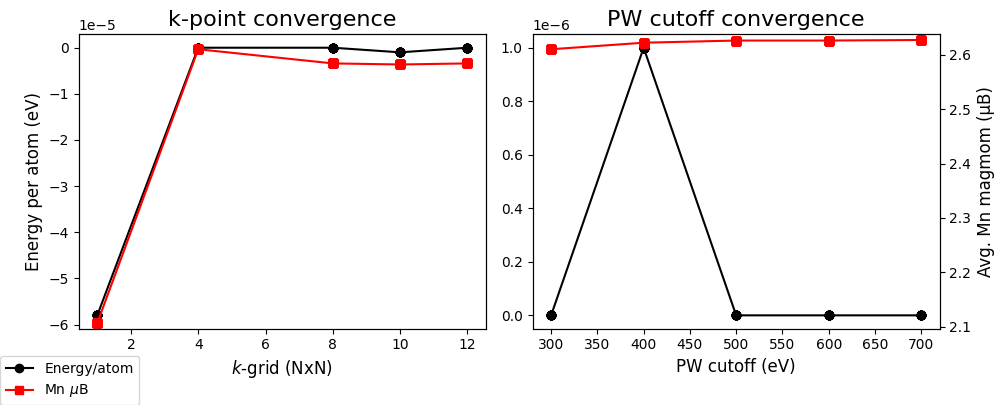

In [7]:
plot_convergence_3(difference)

# Trying both materials in one plot?
Maybe if I plot the difference from the converged value, I can have both materials in one plot

In [9]:
#mnI2
spinspiral = loader(csv_file='../Convergence test MnI2/convergence_results.csv')
fm = loader(csv_file='../Convergence test MnI2/ferromagnetic/convergence_results.csv')

k_energy_diff_mni2 = np.array(spinspiral[1]) - np.array(fm[1])

e_energy_diff_mni2 = np.array(spinspiral[4]) - np.array(fm[4])

difference_mni2 = [spinspiral[0], k_energy_diff_mni2 , spinspiral[2] , spinspiral[3] , e_energy_diff_mni2 , spinspiral[5]]

In [12]:
def convergence_error(arr):
    arr = np.array(arr)
    return np.abs(arr - arr[-1])


def plot_multi_material_convergence(
    results_A,
    results_B,
    labels=("Material A", "Material B"),
    save=False,
    filename="convergence.pdf"
):

    # -----------------------------------
    # unpack
    # -----------------------------------
    kA, eA_k, mA_k, ecA, eA_c, mA_c = results_A
    kB, eB_k, mB_k, ecB, eB_c, mB_c = results_B

    # -----------------------------------
    # convergence errors
    # -----------------------------------
    dE_A_k = convergence_error(eA_k)
    dE_A_c = convergence_error(eA_c)

    dE_B_k = convergence_error(eB_k)
    dE_B_c = convergence_error(eB_c)

    dM_A_k = convergence_error(mA_k)
    dM_A_c = convergence_error(mA_c)

    dM_B_k = convergence_error(mB_k)
    dM_B_c = convergence_error(mB_c)

    # avoid log(0)
    eps = 1e-12

    # -----------------------------------
    # figure
    # -----------------------------------
    fig, axs = plt.subplots(
        2, 2,
        figsize=(10, 7),
        constrained_layout=True
    )

    labelsize = 12
    titlesize = 15

    # ===================================
    # ENERGY vs k-grid
    # ===================================
    ax = axs[0,0]

    ax.plot(
        kA,
        dE_A_k + eps,
        marker='o',
        color='black',
        label=labels[0]
    )

    ax.plot(
        kB,
        dE_B_k + eps,
        marker='s',
        color='red',
        label=labels[1]
    )

    # ax.set_yscale('log')

    ax.set_title("Energy convergence vs k-grid", fontsize=titlesize)
    ax.set_xlabel(r"$k$-grid (NxN)", fontsize=labelsize)
    ax.set_ylabel(r"$|E - E_{\mathrm{conv}}|$ (eV)", fontsize=labelsize)

    # ===================================
    # ENERGY vs cutoff
    # ===================================
    ax = axs[0,1]

    ax.plot(
        ecA,
        dE_A_c + eps,
        marker='o',
        color='black'
    )

    ax.plot(
        ecB,
        dE_B_c + eps,
        marker='s',
        color='red'
    )

    # ax.set_yscale('log')

    ax.set_title("Energy convergence vs cutoff", fontsize=titlesize)
    ax.set_xlabel("PW cutoff (eV)", fontsize=labelsize)

    # ===================================
    # MOMENT vs k-grid
    # ===================================
    ax = axs[1,0]

    ax.plot(
        kA,
        dM_A_k + eps,
        marker='o',
        color='black'
    )

    ax.plot(
        kB,
        dM_B_k + eps,
        marker='s',
        color='red'
    )

    # ax.set_yscale('log')

    ax.set_title("Moment convergence vs k-grid", fontsize=titlesize)
    ax.set_xlabel(r"$k$-grid (NxN)", fontsize=labelsize)
    ax.set_ylabel(r"$|M - M_{\mathrm{conv}}|$ ($\mu_B$)", fontsize=labelsize)

    # ===================================
    # MOMENT vs cutoff
    # ===================================
    ax = axs[1,1]

    ax.plot(
        ecA,
        dM_A_c + eps,
        marker='o',
        color='black'
    )

    ax.plot(
        ecB,
        dM_B_c + eps,
        marker='s',
        color='red'
    )

    # ax.set_yscale('log')

    ax.set_title("Moment convergence vs cutoff", fontsize=titlesize)
    ax.set_xlabel("PW cutoff (eV)", fontsize=labelsize)

    # -----------------------------------
    # global legend
    # -----------------------------------
    fig.legend(
        labels,
        loc='upper center',
        ncol=2,
        fontsize=12
    )

    # -----------------------------------
    # aesthetics
    # -----------------------------------
    for ax in axs.flat:
        ax.grid(alpha=0.3)

    if save:
        plt.savefig(filename, bbox_inches='tight')

    plt.show()

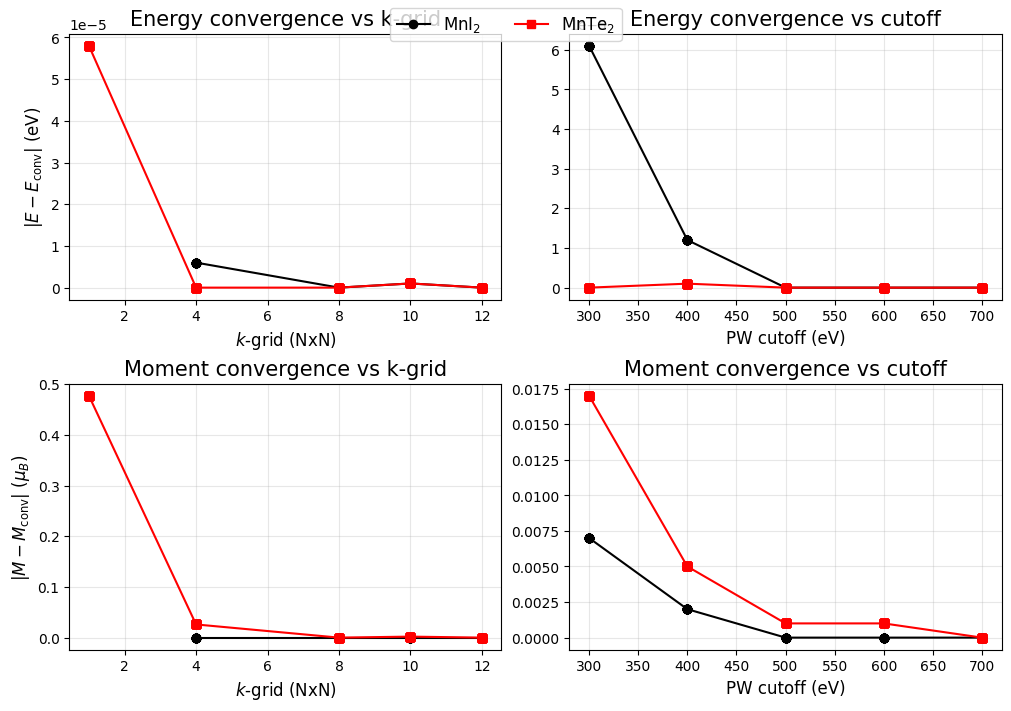

In [13]:
plot_multi_material_convergence(difference_mni2, difference, (r"MnI$_2$" , r"MnTe$_2$"))